In [1]:
%load_ext autoreload
%autoreload 2

/home/codx-junior-projects/codx-junior/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[STATUS] Utilizing all available CPU multi-threading cores for model calculation.
[STATUS] No input image provided. Generating image from text prompt only.
[STATUS] Auto-selected text-to-image model: runwayml/stable-diffusion-v1-5
[STATUS] Loading model: runwayml/stable-diffusion-v1-5
[STATUS] Loading weights into system RAM (Target: CPU)...
[STATUS] Mode: Text-to-Image generation


Executing script directly from image_cli.py...


Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 17.80it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
[STATUS] Model structure compiled successfully on host system RAM.
[STATUS] Beginning execution sequence: Running 10 steps with text prompt: 'Creatr an AI wallpaper about coding'...
100%|██████████| 10/10 [01:43<00:00, 10.40s/it]
[STATUS] Image processing iteration comp


--- OUTPUT DISPLAYED FROM SCRIPT BYTES ---


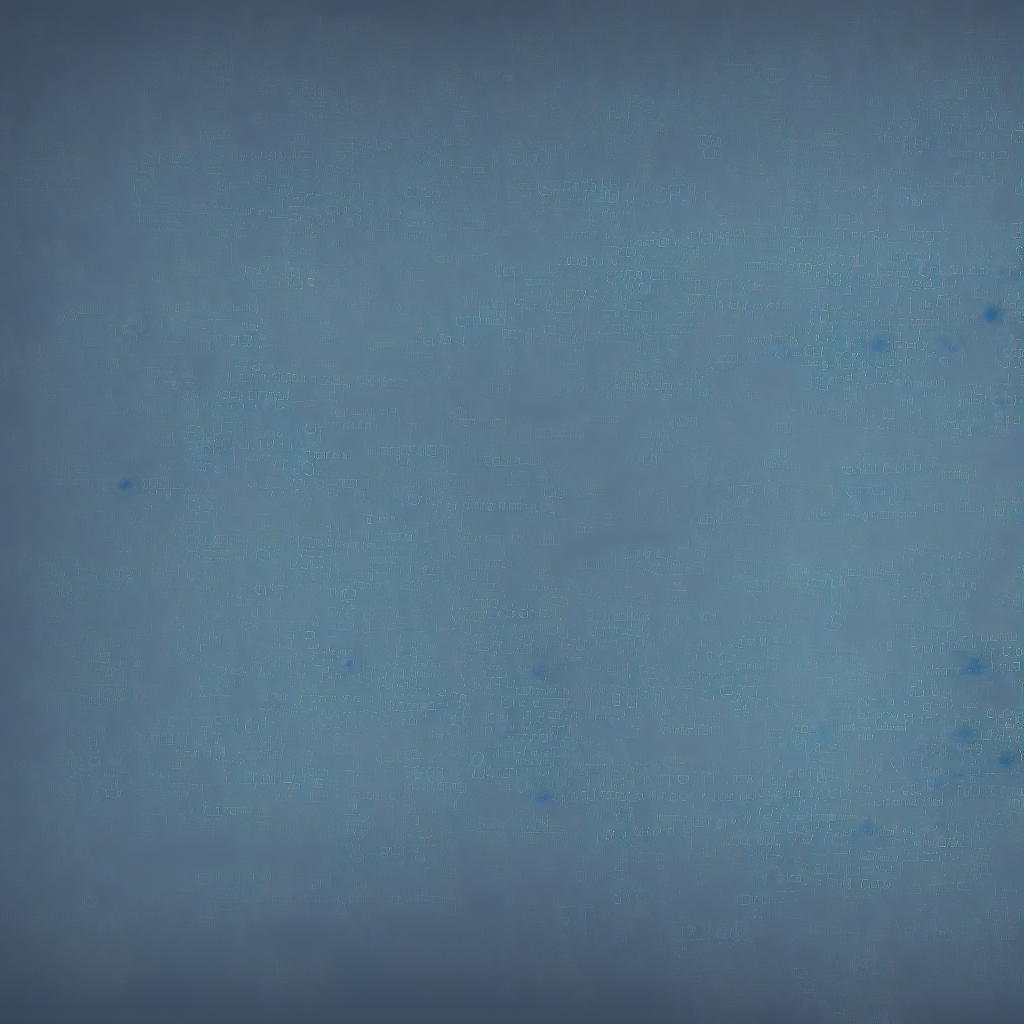

In [2]:
import sys
import io
from unittest.mock import patch, MagicMock
from PIL import Image
from IPython.display import display

# Import the main execution logic directly from your script file
import image_cli

# 1. Mock the command line flags you want to pass to your script
test_args = [
    "image_cli.py", 
    "--prompt", "make it a pencil sketch", 
    "--images", "test.png", 
    "--max_size", "256", 
    "--steps", "10"
]

test_args = [
    "image_cli.py", 
    "--prompt", "Creatr an AI wallpaper about coding", 
    "--max_size", "1024", 
    "--steps", "10"
]

# 2. Execute the script logic and capture the binary output stream
print("Executing script directly from image_cli.py...")
with patch.object(sys, 'argv', test_args):
    # Create a mock stdout with a buffer attribute for Jupyter compatibility
    mock_buffer = io.BytesIO()
    mock_stdout = MagicMock()
    mock_stdout.buffer = mock_buffer
    
    with patch.object(sys, 'stdout', mock_stdout):
        try:
            # This calls your script exactly how the CLI would run it
            image_cli.main()
        except Exception as e:
            print(f"[ERROR] Script execution failed: {e}")
        
        # 3. Extract the generated image bytes from the stream
        image_bytes = mock_buffer.getvalue()

# 4. Display the resulting image inline within the notebook
if image_bytes:
    try:
        output_image = Image.open(io.BytesIO(image_bytes))
        print("\n--- OUTPUT DISPLAYED FROM SCRIPT BYTES ---")
        display(output_image)
    except Exception as e:
        print(f"[ERROR] Failed to parse image: {e}")
else:
    print("[ERROR] No image bytes returned from stdout stream.")